# 🦐 SMARTAMBAK: Notebook Pelatihan & Benchmarking Eksperimen YOLO

Notebook ini dirancang secara terstruktur untuk menjalankan rangkaian eksperimen deteksi dan klasifikasi udang:
- **Section 0:** Setup, Dependencies & Global Configuration
- **Section 1:** Template Download Dataset Roboflow (4 Project)
- **Section 2:** TAHAP 1 - Eliminasi Versi YOLO (Nano: v8, v9, v10, v11, v12, v26)
- **Section 3:** TAHAP 2 - Eksperimen Sumber Dataset (Internal vs External vs Combined)
- **Section 4:** TAHAP 3 - Eksperimen Ketahanan False-Positive (Null Annotations & OOD Test)
- **Section 5:** TAHAP 4 - Eksplorasi Model Scaling (Nano, Small, Medium)
- **Section 6:** TAHAP 5 - Model Klasifikasi *Shrimp & Not Shrimp* (Two-Stage)
- **Section 7:** Dashboard Visualisasi Hasil & Perbandingan Size Model (MB)
- **Section 8:** Ekspor Model Juara ke TensorFlow Lite (TFLite FP16 & INT8)


## Section 0: Setup, Dependencies & Global Configuration
Konfigurasi global diletakkan di sel ini. Cukup ubah parameter di sini untuk mempengaruhi seluruh rangkaian eksperimen.


In [1]:
from IPython.display import display
import os
import glob
import gc
from datetime import datetime
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import torch
from roboflow import Roboflow
from ultralytics import YOLO, settings

# ==========================================
# 0. GLOBAL HYPERPARAMETERS & CONFIGURATION
# ==========================================
EPOCHS = 100
IMGSZ = 640
BATCH = 16
DEVICE = 0 if torch.cuda.is_available() else "cpu"
PROJECT_NAME = "abiyamf/SMARTAMBAK"

# Roboflow Workspace Config
ROBOFLOW_API_KEY = "GtUVpARpe0NaUr5R0m71"
ROBOFLOW_WORKSPACE = "digits-feb-unpad"

# Ultralytics Platform Authentication
settings.update({'api_key': 'ul_8386598a334c3a245f372dbf2071aa1f7f03f5bf'})

# ==========================================
# FUNGSI PEMBERSIH VRAM GPU & MEMORI SISTEM
# ==========================================
def clear_vram():
    """Membersihkan memory cache GPU (VRAM) dan garbage collection sistem."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
    print("🧹 VRAM GPU dan cache memori berhasil dibersihkan.")

print("=== SMARTAMBAK EXPERIMENT SETUP ===")
print(f"Device        : {DEVICE} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")
print(f"Epochs        : {EPOCHS}")
print(f"Image Size    : {IMGSZ}x{IMGSZ}")
print(f"Batch Size    : {BATCH}")
print(f"Project Name  : {PROJECT_NAME}")


=== SMARTAMBAK EXPERIMENT SETUP ===
Device        : 0 (NVIDIA GeForce RTX 5070 Ti)
Epochs        : 100
Image Size    : 640x640
Batch Size    : 16
Project Name  : abiyamf/SMARTAMBAK


## Section 1: Template Download Dataset Roboflow
Template siap pakai untuk mengunduh dataset ke folder `dataset/roboflow/<nama_versi>`.
*Silakan sesuaikan nomor versi (`version(...)`) dan aktifkan (uncomment) baris versi yang ingin Anda unduh.*


In [2]:
rf = Roboflow(api_key=ROBOFLOW_API_KEY)
# ----------------------------------------------------
# 1. Project: shrimp-internal (Data Tim Lapangan)
# ----------------------------------------------------
p_internal = rf.workspace(ROBOFLOW_WORKSPACE).project("shrimp-internal")
# v1: Multiclass Raw (healthy, imnv, wfd, wssv)
ds_internal_v1 = p_internal.version(11).download("yolo26", location="dataset/roboflow/internal_v1_multiclass_raw")

# v2: Multiclass with Augmentation
ds_internal_v2 = p_internal.version(12).download("yolo26", location="dataset/roboflow/internal_v2_multiclass_aug")

# v3: Binary with Augmentation (healthy vs unhealthy)
ds_internal_v3 = p_internal.version(13).download("yolo26", location="dataset/roboflow/internal_v3_binary_aug")

# v4: Binary with 460 Null Annotations
ds_internal_v4 = p_internal.version(14).download("yolo26", location="dataset/roboflow/internal_v4_binary_null")

# v5: Multiclass with 460 Null Annotations (healthy, imnv, wfd, wssv + null)
ds_internal_v5 = p_internal.version(15).download("yolo26", location="dataset/roboflow/internal_v5_multiclass_null")

print("Template download shrimp-internal siap.")


loading Roboflow workspace...
loading Roboflow project...
Template download shrimp-internal siap.


In [3]:
# ----------------------------------------------------
# 2. Project: shrimp-external (Data Internet)
# ----------------------------------------------------
p_external = rf.workspace(ROBOFLOW_WORKSPACE).project("shrimp-external")

# v1: Multiclass Raw (5 kelas: blackgill, healthy, wssv, wssv_bg, yellowhead)
ds_external_v1 = p_external.version(3).download("yolo26", location="dataset/roboflow/external_v1_multiclass_raw")

# v2: Multiclass with Augmentation (5 kelas: blackgill, healthy, wssv, wssv_bg, yellowhead)
ds_external_v2 = p_external.version(4).download("yolo26", location="dataset/roboflow/external_v2_multiclass_aug")

# v3: Multiclass with 460 Null Annotations (5 kelas + null)
ds_external_v3_null = p_external.version(7).download("yolo26", location="dataset/roboflow/external_v3_multiclass_null")

# v4: Binary with Augmentation (healthy vs unhealthy)
ds_external_v3 = p_external.version(5).download("yolo26", location="dataset/roboflow/external_v3_binary_aug")

# v5: Binary with 460 Null Annotations
ds_external_v4 = p_external.version(6).download("yolo26", location="dataset/roboflow/external_v4_binary_null")

print("Template download shrimp-external siap.")


loading Roboflow workspace...
loading Roboflow project...
Template download shrimp-external siap.


In [4]:
# ----------------------------------------------------
# 3. Project: combined-internal-external (Gabungan)
# ----------------------------------------------------
p_combined = rf.workspace(ROBOFLOW_WORKSPACE).project("combined-internal-external")
# v1: Unified Multiclass with Augmentation
ds_combined_v1 = p_combined.version(4).download("yolo26", location="dataset/roboflow/combined_v1_multiclass_aug")

# v2: Unified Binary with Augmentation (healthy vs unhealthy)
ds_combined_v2 = p_combined.version(5).download("yolo26", location="dataset/roboflow/combined_v2_binary_aug")

# v3: Unified Binary with 460 Null Annotations (Final Dataset)
ds_combined_v3 = p_combined.version(6).download("yolo26", location="dataset/roboflow/combined_v3_binary_null")

# v4: Unified Multiclass with 460 Null Annotations (Final Multiclass Dataset)
ds_combined_v4 = p_combined.version(7).download("yolo26", location="dataset/roboflow/combined_v4_multiclass_null")

print("Template download combined-internal-external siap.")


loading Roboflow workspace...
loading Roboflow project...
Template download combined-internal-external siap.


In [5]:
# ----------------------------------------------------
# 4. Project: shrimp and not shrimp (Klasifikasi)
# ----------------------------------------------------
p_cls = rf.workspace(ROBOFLOW_WORKSPACE).project("shrimp-and-not-shrimp")

# v1: Binary Classification Raw (shrimp vs not_shrimp)
ds_cls_v1 = p_cls.version(1).download("folder", location="dataset/roboflow/cls_v1_binary_raw")

# v2: Binary Classification with Augmentation
ds_cls_v2 = p_cls.version(2).download("folder", location="dataset/roboflow/cls_v2_binary_aug")

print("Template download shrimp-and-not-shrimp siap.")


loading Roboflow workspace...
loading Roboflow project...
Template download shrimp-and-not-shrimp siap.


## Section 2: TAHAP 1 - Eliminasi Versi YOLO (Size Paling Kecil: Nano `n`)
Melatih seluruh kandidat model nano pada dataset baseline yang sama untuk menentukan arsitektur mana yang memiliki mAP@0.5 tertinggi dan ukuran paling efisien.

Kandidat resmi:
1. `yolov8n.pt`
2. `yolov9t.pt`
3. `yolov10n.pt`
4. `yolo11n.pt`
5. `yolo12n.pt`
6. `yolo26n.pt`


In [6]:
# Tentukan dataset baseline untuk tahap eliminasi nano
BASELINE_DATA_YAML = "dataset/roboflow/combined_v4_multiclass_null/data.yaml"


In [7]:
# 1.1 Training YOLOv8 Nano
timestamp = datetime.now().strftime("%d-%H-%M")
model_v8n = YOLO("yolov8n.pt")
model_v8n.train(
    data=BASELINE_DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    project=PROJECT_NAME,
    name=f"stage1-yolov8n-{timestamp}",
    exist_ok=True
)

# Bersihkan VRAM GPU setelah training selesai
del model_v8n
clear_vram()


Ultralytics 8.4.155 🚀 Python-3.12.0 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15819MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/roboflow/combined_v4_multiclass_null/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=stag

In [8]:
# 1.2 Training YOLOv9 Tiny/Nano
timestamp = datetime.now().strftime("%d-%H-%M")
model_v9t = YOLO("yolov9t.pt")
model_v9t.train(
    data=BASELINE_DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    project=PROJECT_NAME,
    name=f"stage1-yolov9t-{timestamp}",
    exist_ok=True
)

# Bersihkan VRAM GPU setelah training selesai
del model_v9t
clear_vram()


Ultralytics 8.4.155 🚀 Python-3.12.0 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15819MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/roboflow/combined_v4_multiclass_null/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9t.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=stag

In [9]:
# 1.3 Training YOLOv10 Nano
timestamp = datetime.now().strftime("%d-%H-%M")
model_v10n = YOLO("yolov10n.pt")
model_v10n.train(
    data=BASELINE_DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    project=PROJECT_NAME,
    name=f"stage1-yolov10n-{timestamp}",
    exist_ok=True
)

# Bersihkan VRAM GPU setelah training selesai
del model_v10n
clear_vram()


Ultralytics 8.4.155 🚀 Python-3.12.0 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15819MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/roboflow/combined_v4_multiclass_null/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=sta

In [10]:
# 1.4 Training YOLO11 Nano
timestamp = datetime.now().strftime("%d-%H-%M")
model_11n = YOLO("yolo11n.pt")
model_11n.train(
    data=BASELINE_DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    project=PROJECT_NAME,
    name=f"stage1-yolo11n-{timestamp}",
    exist_ok=True
)

# Bersihkan VRAM GPU setelah training selesai
del model_11n
clear_vram()


Ultralytics 8.4.155 🚀 Python-3.12.0 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15819MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/roboflow/combined_v4_multiclass_null/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=stag

In [11]:
# 1.5 Training YOLO12 Nano
timestamp = datetime.now().strftime("%d-%H-%M")
model_12n = YOLO("yolo12n.pt")
model_12n.train(
    data=BASELINE_DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    project=PROJECT_NAME,
    name=f"stage1-yolo12n-{timestamp}",
    exist_ok=True
)

# Bersihkan VRAM GPU setelah training selesai
del model_12n
clear_vram()


Ultralytics 8.4.155 🚀 Python-3.12.0 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15819MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/roboflow/combined_v4_multiclass_null/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=stag

In [12]:
# 1.6 Training YOLO26 Nano
timestamp = datetime.now().strftime("%d-%H-%M")
model_26n = YOLO("yolo26n.pt")
model_26n.train(
    data=BASELINE_DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    project=PROJECT_NAME,
    name=f"stage1-yolo26n-{timestamp}",
    exist_ok=True
)

# Bersihkan VRAM GPU setelah training selesai
del model_26n
clear_vram()


Ultralytics 8.4.155 🚀 Python-3.12.0 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15819MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/roboflow/combined_v4_multiclass_null/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=stag

### Penetapan Pemenang Tahap 1 (YOLO_BEST_NANO)
Berdasarkan perbandingan mAP dan ukuran bobot model di atas, tentukan nama model terbaik yang akan digunakan untuk tahap selanjutnya.


In [13]:
# Ganti sesuai pemenang Tahap 1 (contoh: "yolo11n.pt" atau "yolo26n.pt")
YOLO_BEST_NANO = "yolo26n.pt"
print(f"Model Pemenang Tahap 1 yang dipilih: {YOLO_BEST_NANO}")


Model Pemenang Tahap 1 yang dipilih: yolo26n.pt


## Section 3: TAHAP 2 - Eksperimen Sumber Dataset
Menguji model arsitektur terbaik (`YOLO_BEST_NANO`) pada ketiga sumber dataset:
1. `shrimp-internal` (Multiclass Augmented)
2. `shrimp-external` (Multiclass Augmented)
3. `combined-internal-external` (Multiclass Unified)


In [14]:
# 2.1 Training pada Shrimp Internal
timestamp = datetime.now().strftime("%d-%H-%M")
model = YOLO(YOLO_BEST_NANO)
model.train(
    data="dataset/roboflow/internal_v2_multiclass_aug/data.yaml",
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    project=PROJECT_NAME,
    name=f"stage2-internal-{timestamp}",
    exist_ok=True
)

# Bersihkan VRAM GPU setelah training selesai
del model
clear_vram()


Ultralytics 8.4.155 🚀 Python-3.12.0 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15819MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/roboflow/internal_v2_multiclass_aug/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=stage

In [15]:
# 2.2 Training pada Shrimp External
timestamp = datetime.now().strftime("%d-%H-%M")
model = YOLO(YOLO_BEST_NANO)
model.train(
    data="dataset/roboflow/external_v2_multiclass_aug/data.yaml",
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    project=PROJECT_NAME,
    name=f"stage2-external-{timestamp}",
    exist_ok=True
)

# Bersihkan VRAM GPU setelah training selesai
del model
clear_vram()


Ultralytics 8.4.155 🚀 Python-3.12.0 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15819MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/roboflow/external_v2_multiclass_aug/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=stage

In [16]:
# 2.3 Training pada Combined Internal + External
timestamp = datetime.now().strftime("%d-%H-%M")
model = YOLO(YOLO_BEST_NANO)
model.train(
    data="dataset/roboflow/combined_v1_multiclass_aug/data.yaml",
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    project=PROJECT_NAME,
    name=f"stage2-combined-{timestamp}",
    exist_ok=True
)

# Bersihkan VRAM GPU setelah training selesai
del model
clear_vram()


New https://pypi.org/project/ultralytics/8.4.156 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.155 🚀 Python-3.12.0 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15819MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/roboflow/combined_v1_multiclass_aug/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det

## Section 4: TAHAP 3 - Eksperimen Ketahanan False-Positive (Null Annotations)
Menguji model dengan penambahan **460 gambar negatif** (*null annotations*) untuk mengevaluasi ketahanan model terhadap deteksi palsu pada manusia, tangan, air, ikan, dll.

Eksperimen mencakup:
1. **Multiclass Null:** Mendeteksi kelas penyakit (`healthy`, `imnv`, `wfd`, `wssv`, dll) tanpa false alarm pada objek non-udang.
2. **Binary Null:** Mendeteksi `healthy` vs `unhealthy` tanpa false alarm pada objek non-udang.
3. **OOD Benchmark:** Menguji model pada 400 gambar non-udang (`dataset/OOD_TEST`).


In [17]:
# 3.1 Training Multiclass dengan Null Annotations
# Melatih detektor multi-penyakit yang tahan terhadap false alarm objek non-udang
timestamp = datetime.now().strftime("%d-%H-%M")
model_multi_null = YOLO(YOLO_BEST_NANO)

# Pilih dataset multiclass null:
# - internal_v5_multiclass_null: "dataset/roboflow/internal_v5_multiclass_null/data.yaml"
# - combined_v4_multiclass_null: "dataset/roboflow/combined_v4_multiclass_null/data.yaml"
# - external_v3_multiclass_null: "dataset/roboflow/external_v3_multiclass_null/data.yaml"
DATA_MULTICLASS_NULL = "dataset/roboflow/combined_v4_multiclass_null/data.yaml"

model_multi_null.train(
    data=DATA_MULTICLASS_NULL,
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    project=PROJECT_NAME,
    name=f"stage3-multiclass-null-{timestamp}",
    exist_ok=True
)

# Bersihkan VRAM GPU setelah training selesai
del model_multi_null
clear_vram()


New https://pypi.org/project/ultralytics/8.4.156 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.155 🚀 Python-3.12.0 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15819MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/roboflow/combined_v4_multiclass_null/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_de

In [18]:
# 3.2 Training Binary (Healthy vs Unhealthy) dengan Null Annotations
# Melatih detektor udang biner yang tahan terhadap false alarm objek non-udang
timestamp = datetime.now().strftime("%d-%H-%M")
model_binary_null = YOLO(YOLO_BEST_NANO)

# Pilih dataset biner null:
# - combined_v3_binary_null: "dataset/roboflow/combined_v3_binary_null/data.yaml"
# - internal_v4_binary_null: "dataset/roboflow/internal_v4_binary_null/data.yaml"
DATA_BINARY_NULL = "dataset/roboflow/combined_v3_binary_null/data.yaml"

model_binary_null.train(
    data=DATA_BINARY_NULL,
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    project=PROJECT_NAME,
    name=f"stage3-binary-null-{timestamp}",
    exist_ok=True
)

# Bersihkan VRAM GPU setelah training selesai
del model_binary_null
clear_vram()


New https://pypi.org/project/ultralytics/8.4.156 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.155 🚀 Python-3.12.0 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15819MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/roboflow/combined_v3_binary_null/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=30

In [19]:
# 3.3 Benchmark OOD (Out-of-Distribution) pada 400 Gambar Non-Udang (dataset/OOD_TEST)
def run_ood_benchmark(weights_path_or_model, label="Model"):
    ood_folder = Path("dataset/OOD_TEST")
    if not ood_folder.exists():
        print("Folder dataset/OOD_TEST tidak ditemukan. Jalankan script dataset_splitter.py terlebih dahulu.")
        return
    ood_images = list(ood_folder.glob("*/*.jpg"))
    if not ood_images:
        print("Tidak ada gambar di folder dataset/OOD_TEST.")
        return
    
    # Load model jika input adalah path weights
    if isinstance(weights_path_or_model, (str, Path)):
        if not os.path.exists(str(weights_path_or_model)):
            print(f"File weights tidak ditemukan: {weights_path_or_model}")
            return
        model_instance = YOLO(str(weights_path_or_model))
    else:
        model_instance = weights_path_or_model

    # Jalankan inferensi dalam mini-batch (chunk size 32) untuk menghindari OutOfMemoryError CUDA
    CHUNK_SIZE = 32
    images_with_fp = 0
    
    for chunk_start in range(0, len(ood_images), CHUNK_SIZE):
        chunk = [str(p) for p in ood_images[chunk_start : chunk_start + CHUNK_SIZE]]
        results = model_instance.predict(source=chunk, conf=0.25, verbose=False)
        images_with_fp += sum(1 for r in results if len(r.boxes) > 0)
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            
    ood_fpr = (images_with_fp / len(ood_images)) * 100
    
    print("=" * 50)
    print(f"Evaluasi OOD: {label}")
    print(f"Total Gambar OOD                : {len(ood_images)}")
    print(f"Gambar Menghasilkan False Alarm : {images_with_fp}")
    print(f"OOD False Positive Rate (FPR)   : {ood_fpr:.2f}%")
    print("=" * 50 + "\n")

    # Bersihkan VRAM GPU setelah evaluasi OOD selesai
    del model_instance
    clear_vram()

# Cari weights terbaru untuk Multiclass Null
multi_null_runs = sorted(glob.glob(f"runs/detect/{PROJECT_NAME}/stage3-multiclass-null*/weights/best.pt"), key=os.path.getmtime, reverse=True)
if multi_null_runs:
    run_ood_benchmark(multi_null_runs[0], "Stage 3 - Multiclass Null")

# Cari weights terbaru untuk Binary Null
binary_null_runs = sorted(glob.glob(f"runs/detect/{PROJECT_NAME}/stage3-binary-null*/weights/best.pt"), key=os.path.getmtime, reverse=True)
if binary_null_runs:
    run_ood_benchmark(binary_null_runs[0], "Stage 3 - Binary Null")


[W920 06:21:35.576420257 CUDACachingAllocator.cpp:3934] memory allocation failed with OOM on device 0 while trying to allocate 3277848576 bytes (free: 2705915904, total: 16587751424).


Evaluasi OOD: Stage 3 - Multiclass Null
Total Gambar OOD                : 400
Gambar Menghasilkan False Alarm : 4
OOD False Positive Rate (FPR)   : 1.00%

🧹 VRAM GPU dan cache memori berhasil dibersihkan.


[W920 06:21:38.668713356 CUDACachingAllocator.cpp:3934] memory allocation failed with OOM on device 0 while trying to allocate 3277848576 bytes (free: 2709061632, total: 16587751424).


Evaluasi OOD: Stage 3 - Binary Null
Total Gambar OOD                : 400
Gambar Menghasilkan False Alarm : 2
OOD False Positive Rate (FPR)   : 0.50%

🧹 VRAM GPU dan cache memori berhasil dibersihkan.


## Section 5: TAHAP 4 - Eksplorasi Model Scaling (Nano -> Small -> Medium)
Menguji trade-off antara peningkatan akurasi (mAP50) vs pertambahan ukuran bobot (MB) dan latensi inferensi pada arsitektur pemenang.


In [20]:
# Tentukan base model family dari pemenang Tahap 1 (misal: "yolo11" atau "yolo26")
FAMILY = "yolo26"  # Sesuaikan dengan versi terbaik Anda

# Tentukan dataset terbaik untuk scaling Small & Medium (Bisa Multiclass Null atau Binary Null)
SCALING_DATA_YAML = "dataset/roboflow/combined_v4_multiclass_null/data.yaml"  # atau internal_v5_multiclass_null
print(f"Family Model: {FAMILY} | Dataset Scaling: {SCALING_DATA_YAML}")


Family Model: yolo26 | Dataset Scaling: dataset/roboflow/combined_v4_multiclass_null/data.yaml


In [21]:
# 4.1 Scaled Small
timestamp = datetime.now().strftime("%d-%H-%M")
model_s = YOLO(f"{FAMILY}s.pt")
model_s.train(
    data=SCALING_DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    project=PROJECT_NAME,
    name=f"stage4-scale-small-{timestamp}",
    exist_ok=True
)

# Bersihkan VRAM GPU setelah training selesai
del model_s
clear_vram()


New https://pypi.org/project/ultralytics/8.4.156 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.155 🚀 Python-3.12.0 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15819MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/roboflow/combined_v4_multiclass_null/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_de

In [22]:
# 4.2 Scaled Medium
timestamp = datetime.now().strftime("%d-%H-%M")
model_m = YOLO(f"{FAMILY}m.pt")
model_m.train(
    data=SCALING_DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    project=PROJECT_NAME,
    name=f"stage4-scale-medium-{timestamp}",
    exist_ok=True
)

# Bersihkan VRAM GPU setelah training selesai
del model_m
clear_vram()


New https://pypi.org/project/ultralytics/8.4.156 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.155 🚀 Python-3.12.0 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15819MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/roboflow/combined_v4_multiclass_null/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_de

## Section 6: TAHAP 5 - Training Model Klasifikasi 'shrimp and not shrimp' (Two-Stage)
Melatih model klasifikasi (YOLO-cls) untuk arsitektur dua tahap (*Two-Stage Pipeline*).


In [2]:
# 5.1 Training Classifier Model
timestamp = datetime.now().strftime("%d-%H-%M")
model_cls = YOLO("yolo26n-cls.pt")
model_cls.train(
    data="dataset/roboflow/cls_v2_binary_aug",
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    project=PROJECT_NAME,
    name=f"stage5-cls-shrimp-not-shrimp-{timestamp}",
    exist_ok=True
)

# Bersihkan VRAM GPU setelah training selesai
del model_cls
clear_vram()


New https://pypi.org/project/ultralytics/8.4.156 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.155 🚀 Python-3.12.0 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15819MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/roboflow/cls_v2_binary_aug, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mo

## Section 7: Dashboard Visualisasi Hasil & Perbandingan Size Model (MB)
Membaca otomatis seluruh file `results.csv` dan bobot `best.pt` dari folder `runs/detect/abiyamf/SMARTAMBAK/` untuk:
1. **Perbandingan Ukuran Model dalam MB** untuk setiap model yang dilatih.
2. **Perbandingan Akurasi (mAP@0.5 & mAP@0.5:0.95)**.
3. **Scatter Plot Pareto (Ukuran MB vs mAP@0.5)** untuk memilih model paling ideal bagi aplikasi mobile.


In [3]:
# Mengumpulkan seluruh hasil run & menghitung ukuran model dalam MB
run_dirs = sorted(glob.glob("runs/detect/abiyamf/SMARTAMBAK/*"))
summary_records = []

for rdir in run_dirs:
    csv_file = os.path.join(rdir, "results.csv")
    weights_file = os.path.join(rdir, "weights", "best.pt")
    
    # Hitung size model jika file weights best.pt tersedia
    size_mb = 0.0
    if os.path.exists(weights_file):
        size_mb = round(os.path.getsize(weights_file) / (1024 * 1024), 2)
    elif os.path.exists(os.path.join(rdir, "weights", "last.pt")):
        size_mb = round(os.path.getsize(os.path.join(rdir, "weights", "last.pt")) / (1024 * 1024), 2)

    if os.path.exists(csv_file):
        try:
            df_run = pd.read_csv(csv_file)
            df_run.columns = [c.strip() for c in df_run.columns]
            last_row = df_run.iloc[-1]
            
            run_name = os.path.basename(rdir)
            map50 = last_row.get("metrics/mAP50(B)", 0.0)
            map50_95 = last_row.get("metrics/mAP50-95(B)", 0.0)
            precision = last_row.get("metrics/precision(B)", 0.0)
            recall = last_row.get("metrics/recall(B)", 0.0)
            
            summary_records.append({
                "Run Name": run_name,
                "Model Size (MB)": size_mb,
                "mAP50": round(map50, 4),
                "mAP50-95": round(map50_95, 4),
                "Precision": round(precision, 4),
                "Recall": round(recall, 4)
            })
        except Exception as e:
            continue

df_summary = pd.DataFrame(summary_records)

if not df_summary.empty:
    print(f"Ditemukan {len(df_summary)} hasil eksperimen:")
    display(df_summary.sort_values(by="mAP50", ascending=False))
else:
    print("Belum ada runs yang selesai dieksekusi atau folder runs masih kosong.")


Ditemukan 27 hasil eksperimen:


,Run Name,Model Size (MB),mAP50,mAP50-95,Precision,Recall
23,stage3-binary-null-20-05-38,5.15,0.9926,0.9053,0.9807,0.9872
22,stage2-internal-20-03-40,5.15,0.9892,0.9184,0.9900,0.9872
5,stage1-yolo12n-20-02-15,5.28,0.9772,0.9095,0.9598,0.9368
2,stage1-yolo11n-20-01-43,5.23,0.9747,0.9050,0.9121,0.9638
25,stage4-scale-medium-20-07-15,42.01,0.9732,0.9124,0.9544,0.9399
15,stage1-yolov8n-19-23-42,5.97,0.9712,0.9007,0.9500,0.9306
20,stage2-combined-20-04-18,5.15,0.9712,0.9044,0.9583,0.9505
18,stage1-yolov9t-20-00-11,4.44,0.9663,0.9014,0.9600,0.9194
11,stage1-yolov10n-20-01-03,5.50,0.9642,0.8920,0.9265,0.9415
26,stage4-scale-small-20-06-21,19.39,0.9629,0.9084,0.9579,0.9515


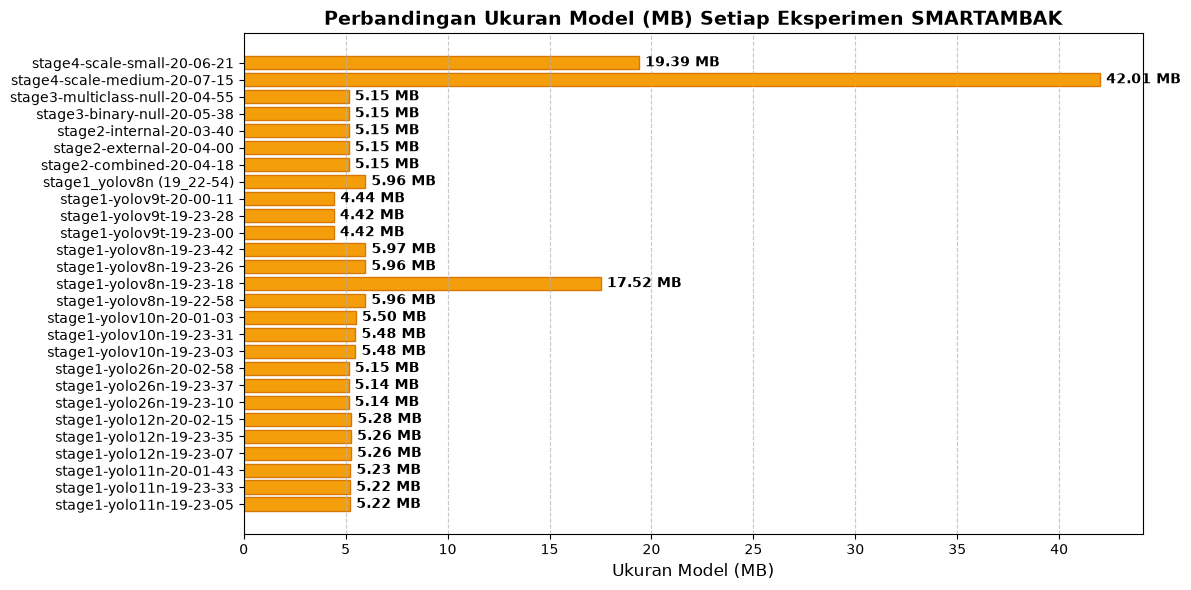

In [4]:
# 1. Grafik Perbandingan Ukuran Model (Size dalam MB)
if not df_summary.empty:
    plt.figure(figsize=(12, 6))
    bars = plt.barh(df_summary["Run Name"], df_summary["Model Size (MB)"], color="#f59e0b", edgecolor="#d97706")
    plt.xlabel("Ukuran Model (MB)", fontsize=12)
    plt.title("Perbandingan Ukuran Model (MB) Setiap Eksperimen SMARTAMBAK", fontsize=14, fontweight="bold")
    plt.grid(axis="x", linestyle="--", alpha=0.7)
    for bar in bars:
        w = bar.get_width()
        plt.text(w + 0.3, bar.get_y() + bar.get_height()/2, f"{w:.2f} MB", va="center", fontweight="bold")
    plt.tight_layout()
    plt.show()


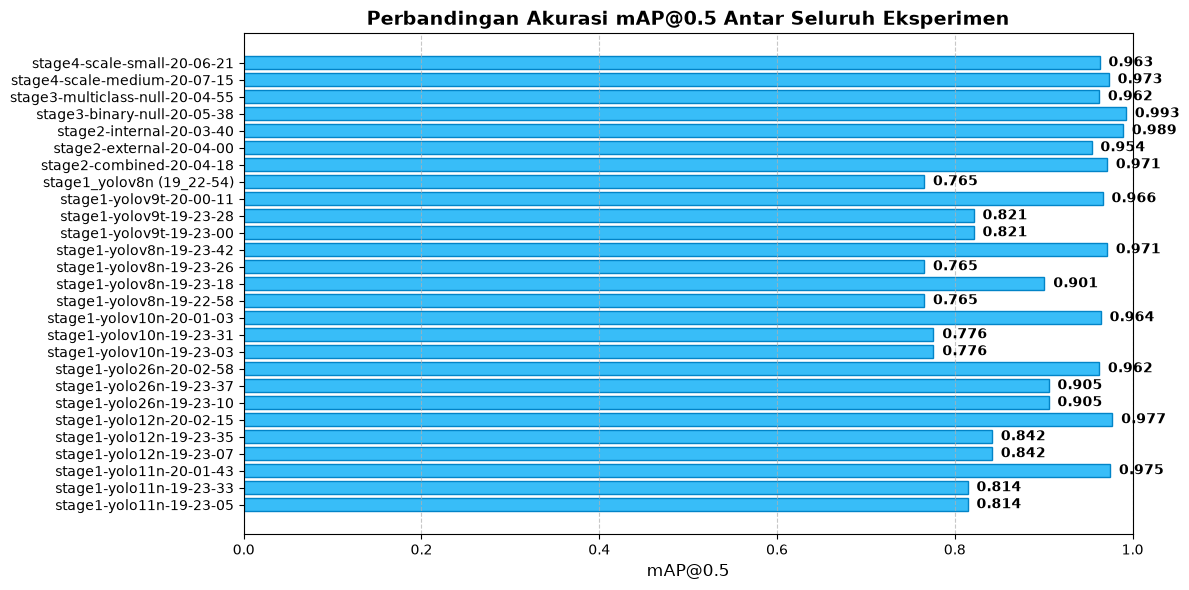

In [5]:
# 2. Grafik Perbandingan Akurasi (mAP@0.5)
if not df_summary.empty:
    plt.figure(figsize=(12, 6))
    bars = plt.barh(df_summary["Run Name"], df_summary["mAP50"], color="#38bdf8", edgecolor="#0284c7")
    plt.xlabel("mAP@0.5", fontsize=12)
    plt.title("Perbandingan Akurasi mAP@0.5 Antar Seluruh Eksperimen", fontsize=14, fontweight="bold")
    plt.xlim(0, 1.0)
    plt.grid(axis="x", linestyle="--", alpha=0.7)
    for bar in bars:
        w = bar.get_width()
        plt.text(w + 0.01, bar.get_y() + bar.get_height()/2, f"{w:.3f}", va="center", fontweight="bold")
    plt.tight_layout()
    plt.show()


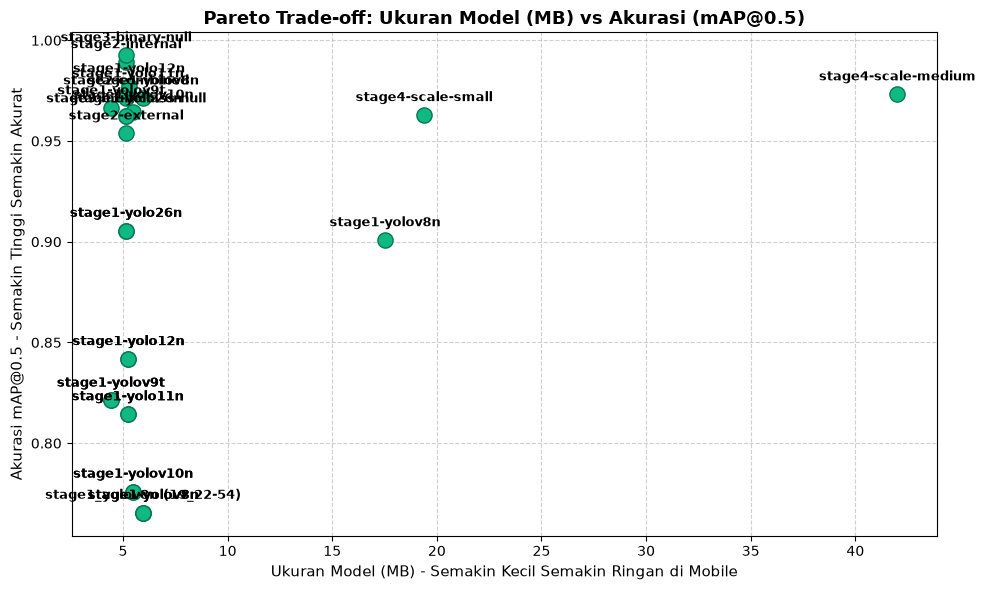

In [6]:
# 3. Scatter Plot Pareto: Ukuran Model (MB) vs Akurasi (mAP@0.5)
if not df_summary.empty and (df_summary["Model Size (MB)"] > 0).any():
    plt.figure(figsize=(10, 6))
    plt.scatter(df_summary["Model Size (MB)"], df_summary["mAP50"], color="#10b981", s=120, edgecolor="#047857", zorder=3)
    
    for i, row in df_summary.iterrows():
        plt.annotate(
            "-".join(row["Run Name"].split("-")[:-3]) if len(row["Run Name"].split("-")) > 3 else row["Run Name"], 
            (row["Model Size (MB)"], row["mAP50"]),
            textcoords="offset points", 
            xytext=(0, 10), 
            ha='center',
            fontsize=9,
            fontweight="bold"
        )
        
    plt.xlabel("Ukuran Model (MB) - Semakin Kecil Semakin Ringan di Mobile", fontsize=11)
    plt.ylabel("Akurasi mAP@0.5 - Semakin Tinggi Semakin Akurat", fontsize=11)
    plt.title("Pareto Trade-off: Ukuran Model (MB) vs Akurasi (mAP@0.5)", fontsize=13, fontweight="bold")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()


## Section 8: Ekspor Model Terbaik ke TensorFlow Lite (TFLite / LiteRT)
Setelah menentukan model juara berdasarkan kombinasi mAP, ketahanan OOD, dan ukuran MB paling efisien, ekspor model ke format `.tflite` untuk deployment aplikasi mobile (Flutter/Kotlin Android & iOS).

Format ekspor mencakup:
1. **Dynamic INT8 (`quantize="w8a32"`):** Bobot model terkuantisasi 8-bit, memotong ukuran ~70% tanpa butuh dataset kalibrasi.
2. **Standar FP32 (`format="tflite"`):** Model floating-point presisi penuh untuk benchmarking.
3. **Full INT8 (`int8=True`):** Kuantisasi integer penuh (bobot + aktivasi) menggunakan dataset kalibrasi untuk mobile NPU/DSP.


In [7]:
# Otomatis mendeteksi best.pt terbaru dari runs, atau tentukan path manual
manual_weights_path = "runs/detect/abiyamf/SMARTAMBAK/stage3-binary-null-20-05-38/weights/best.pt"  # Contoh manual: "runs/detect/abiyamf/SMARTAMBAK/stage3-binary-null-xx/weights/best.pt"

best_weights_file = None
if manual_weights_path and os.path.exists(manual_weights_path):
    best_weights_file = manual_weights_path
else:
    all_best_pts = glob.glob(f"runs/detect/{PROJECT_NAME}/*/weights/best.pt")
    if all_best_pts:
        all_best_pts.sort(key=os.path.getmtime, reverse=True)
        best_weights_file = all_best_pts[0]

if best_weights_file and os.path.exists(best_weights_file):
    print(f"Model weights yang dipilih : {best_weights_file}")
    champion_model = YOLO(best_weights_file)
    orig_size_mb = os.path.getsize(best_weights_file) / (1024 * 1024)
    print(f"Ukuran PyTorch Asli (.pt)  : {orig_size_mb:.2f} MB\n")
    
    # 1. Ekspor ke TFLite Dynamic INT8 (w8a32: bobot INT8 + aktivasi FP32, hemat ~70%, tanpa butuh kalibrasi)
    print("[1] Mengekspor ke TFLite Dynamic INT8 (w8a32)...\n")
    try:
        tflite_dyn = champion_model.export(format="tflite", quantize="w8a32", imgsz=IMGSZ)
        dyn_size_mb = os.path.getsize(tflite_dyn) / (1024 * 1024)
        print(f"-> File Dynamic INT8 : {tflite_dyn}")
        print(f"-> Size Dynamic INT8 : {dyn_size_mb:.2f} MB (Hemat {(1 - dyn_size_mb/orig_size_mb)*100:.1f}%)\n")
    except Exception as e:
        print(f"Export Dynamic INT8 gagal: {e}\n")

    # 2. Ekspor ke TFLite Standar (FP32)
    print("[2] Mengekspor ke TFLite Standar (FP32)...\n")
    try:
        tflite_fp32 = champion_model.export(format="tflite", imgsz=IMGSZ)
        fp32_size_mb = os.path.getsize(tflite_fp32) / (1024 * 1024)
        print(f"-> File FP32 : {tflite_fp32}")
        print(f"-> Size FP32 : {fp32_size_mb:.2f} MB\n")
    except Exception as e:
        print(f"Export FP32 gagal: {e}\n")

    # 3. Ekspor ke TFLite Full INT8 (Membutuhkan representatif data kalibrasi)
    calibration_data = "dataset/roboflow/combined_v3_binary_null/data.yaml"
    if not os.path.exists(calibration_data):
        calibration_data = "dataset/roboflow/internal_v4_binary_null/data.yaml"
    if not os.path.exists(calibration_data):
        calibration_data = BASELINE_DATA_YAML

    print(f"[3] Mengekspor ke TFLite Full INT8 (Kalibrasi: {calibration_data})...\n")
    try:
        tflite_int8 = champion_model.export(
            format="tflite", 
            int8=True, 
            data=calibration_data, 
            imgsz=IMGSZ
        )
        int8_size_mb = os.path.getsize(tflite_int8) / (1024 * 1024)
        print(f"-> File Full INT8 : {tflite_int8}")
        print(f"-> Size Full INT8 : {int8_size_mb:.2f} MB (Hemat {(1 - int8_size_mb/orig_size_mb)*100:.1f}%)\n")
    except Exception as e:
        print(f"Export Full INT8 gagal: {e}")
        print("Catatan: Pastikan file data.yaml kalibrasi tersedia dan valid.\n")

    # Bersihkan VRAM setelah export selesai
    del champion_model
    clear_vram()
else:
    print(f"Belum ada file weights yang ditemukan di runs/detect/{PROJECT_NAME}/.")
    print("Selesaikan salah satu eksperimen training terlebih dahulu.")


Model weights yang dipilih : runs/detect/abiyamf/SMARTAMBAK/stage3-binary-null-20-05-38/weights/best.pt
Ukuran PyTorch Asli (.pt)  : 5.15 MB
[1] Mengekspor ke TFLite FP16...
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ format='tflite' is deprecated as of 8.4.83 and has been replaced by the unified Google LiteRT format. Exporting format='litert' instead. See https://docs.ultralytics.com/integrations/litert
Ultralytics 8.4.155 🚀 Python-3.12.0 torch-2.14.0+cu130 CPU (AMD Ryzen 7 8700F 8-Core Processor)
Export to tflite in the cloud with Ultralytics Platform: https://platform.ultralytics.com


AssertionError: ERROR ❌️ quantize=16 (FP16) is not supported; format='litert' supports quantize=8 (INT8), 'w8a16' (INT8 weights + INT16 activations), 'w8a32' (dynamic INT8), 32 or None (FP32). See https://docs.ultralytics.com/modes/export#quantization-options